## Red dot tracker

In [ ]:
import cv2
import numpy as np
import pandas as pd
import os

# === Folder containing videos ===
folder_path = r"C:\Users\Justine Elvena\Desktop\Acads\UPD\Sem4.1\Physics192\Inertial Balance\Vids"

# === Define target color range in HSV ===
# Red wraps around the hue range, so we combine two masks.
lower_red1 = np.array([0, 70, 70])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 70, 70])
upper_red2 = np.array([180, 255, 255])

# === Supported video formats ===
video_exts = ('.mov', '.mp4', '.avi', '.mkv', '.wmv')

# === Helper: click event callback ===
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        param["point"] = (x, y)
        print(f"Reference point selected: {param['point']}")
        cv2.destroyWindow("Select Reference Point")

# === Loop through all files ===
for filename in os.listdir(folder_path):
    #if not filename.lower().endswith(video_exts):
    #    continue

    if filename != "Test1.MOV":
        continue

    video_path = os.path.join(folder_path, filename)
    output_csv = os.path.splitext(video_path)[0] + "_positions.csv"

    print(f"\nProcessing: {filename}")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Cannot open {filename}")
        continue

    # === Show first frame for manual reference selection ===
    ret, first_frame = cap.read()
    if not ret:
        print(f"❌ Cannot read {filename}")
        cap.release()
        continue

    # --- Reset click container for each video ---
    click_data = {"point": None}

    # Ask user to click the reference (black dot)
    cv2.imshow("Select Reference Point", first_frame)
    cv2.setMouseCallback("Select Reference Point", click_event, click_data)
    print("🖱️ Click the black reference dot in the window.")

    # Wait for user to click
    while click_data["point"] is None:
        if cv2.waitKey(20) & 0xFF == 27:  # Escape to skip
            break
    ref_point = click_data["point"]
    if ref_point is None:
        print("⚠️ No reference selected — skipping this video.")
        cap.release()
        cv2.destroyAllWindows()
        continue

    ref_x, ref_y = ref_point
    cv2.destroyAllWindows()
    print(f"✅ Reference point for {filename}: ({ref_x}, {ref_y})")

    # Reset to start
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    positions = []
    frame_idx = 0

    # === Process frames ===
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        # Threshold for red (combine two ranges)
        mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
        mask = cv2.bitwise_or(mask1, mask2)

        # Clean up noise
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c = max(contours, key=cv2.contourArea)
            M = cv2.moments(c)
            if M["m00"] > 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                dx = cx - ref_x
                dy = cy - ref_y
                positions.append((frame_idx, cx, cy, dx, dy))
            else:
                positions.append((frame_idx, np.nan, np.nan, np.nan, np.nan))
        else:
            positions.append((frame_idx, np.nan, np.nan, np.nan, np.nan))

    cap.release()

    # === Save CSV ===
    df = pd.DataFrame(positions, columns=["frame", "x", "y", "dx_from_ref", "dy_from_ref"])
    df.to_csv(output_csv, index=False)
    print(f"✅ Saved: {output_csv}")

print("\n🎉 All videos processed!")



Processing: Test1.MOV
🖱️ Click the black reference dot in the window.
⚠️ No reference selected — skipping this video.

🎉 All videos processed!


## Green dot tracker

In [9]:
import cv2
import numpy as np
import pandas as pd
import os

# === Folder containing videos ===
folder_path = r"C:\Users\Justine Elvena\Desktop\Acads\UPD\Sem4.1\Physics192\Inertial Balance\Vids"

# === Define target color range in HSV ===
# For green (~#00ff00)
# You can fine-tune these if needed
lower_hsv = np.array([40, 70, 70])
upper_hsv = np.array([80, 255, 255])

# === Supported video formats ===
video_exts = ('.mov', '.mp4', '.avi', '.mkv', '.wmv')

# === Helper: click event callback ===
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        param["point"] = (x, y)
        print(f"Reference point selected: {param['point']}")
        cv2.destroyWindow("Select Reference Point")

# === Loop through all files ===
for filename in os.listdir(folder_path):
    if not filename.lower().endswith(video_exts):
        continue

    video_path = os.path.join(folder_path, filename)
    output_csv = os.path.splitext(video_path)[0] + "_positions.csv"

    print(f"\nProcessing: {filename}")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Cannot open {filename}")
        continue

    # === Show first frame for manual reference selection ===
    ret, first_frame = cap.read()
    if not ret:
        print(f"❌ Cannot read {filename}")
        cap.release()
        continue

    # --- Reset click container for each video ---
    click_data = {"point": None}

    # Ask user to click the reference (black dot)
    cv2.imshow("Select Reference Point", first_frame)
    cv2.setMouseCallback("Select Reference Point", click_event, click_data)
    print("🖱️ Click the black reference dot in the window.")

    # Wait for user to click
    while click_data["point"] is None:
        if cv2.waitKey(20) & 0xFF == 27:  # Escape to skip
            break
    ref_point = click_data["point"]
    if ref_point is None:
        print("⚠️ No reference selected — skipping this video.")
        cap.release()
        cv2.destroyAllWindows()
        continue

    ref_x, ref_y = ref_point
    cv2.destroyAllWindows()
    print(f"✅ Reference point for {filename}: ({ref_x}, {ref_y})")

    # Reset to start
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    positions = []
    frame_idx = 0

    # === Process frames ===
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        # Threshold for green
        mask = cv2.inRange(hsv, lower_hsv, upper_hsv)

        # Clean up noise
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c = max(contours, key=cv2.contourArea)
            M = cv2.moments(c)
            if M["m00"] > 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                dx = cx - ref_x
                dy = cy - ref_y
                positions.append((frame_idx, cx, cy, dx, dy))
            else:
                positions.append((frame_idx, np.nan, np.nan, np.nan, np.nan))
        else:
            positions.append((frame_idx, np.nan, np.nan, np.nan, np.nan))

    cap.release()

    # === Save CSV ===
    df = pd.DataFrame(positions, columns=["frame", "x", "y", "dx_from_ref", "dy_from_ref"])
    df.to_csv(output_csv, index=False)
    print(f"✅ Saved: {output_csv}")

print("\n🎉 All videos processed!")


Processing: string1.MOV
🖱️ Click the black reference dot in the window.
Reference point selected: (1094, 485)
✅ Reference point for string1.MOV: (1094, 485)
✅ Saved: C:\Users\Justine Elvena\Desktop\Acads\UPD\Sem4.1\Physics192\Inertial Balance\Vids\string1_positions.csv

Processing: string2.MOV
🖱️ Click the black reference dot in the window.
Reference point selected: (1022, 478)
✅ Reference point for string2.MOV: (1022, 478)
✅ Saved: C:\Users\Justine Elvena\Desktop\Acads\UPD\Sem4.1\Physics192\Inertial Balance\Vids\string2_positions.csv

Processing: string3.MOV
🖱️ Click the black reference dot in the window.
Reference point selected: (1098, 496)
✅ Reference point for string3.MOV: (1098, 496)
✅ Saved: C:\Users\Justine Elvena\Desktop\Acads\UPD\Sem4.1\Physics192\Inertial Balance\Vids\string3_positions.csv

Processing: Test1.MOV
🖱️ Click the black reference dot in the window.
Reference point selected: (1057, 499)
✅ Reference point for Test1.MOV: (1057, 499)
✅ Saved: C:\Users\Justine Elvena\

## Detection where frame by frame shot of recorded video is shown ##

To be done only for string1 and noload

In [1]:
import cv2
import os
import numpy as np
import pandas as pd

def recordSingleShowFrames(video_path, output_dir):
    base_name = os.path.splitext(os.path.basename(video_path))[0] 
    output_csv = os.path.join(output_dir, base_name + "_positions.csv")

    # === Target color range in HSV (green) ===
    lower_hsv = np.array([40, 50, 100])
    upper_hsv = np.array([80, 255, 255])

    # === Click callback for reference point and pause selection ===
    def click_event(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            param["point"] = (x, y)
            print(f"Point selected: {param['point']}")

    # === Open video ===
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    # === Select reference point ===
    ret, first_frame = cap.read()
    if not ret:
        raise RuntimeError("Cannot read first frame")

    # Make the window resizable
    cv2.namedWindow("Select Reference Point", cv2.WINDOW_NORMAL)

    # Optionally resize frame to fit your screen
    frame_h, frame_w = first_frame.shape[:2]
    max_width = 1200  # Adjust to fit your screen
    if frame_w > max_width:
        scale = max_width / frame_w
        first_frame = cv2.resize(first_frame, (0, 0), fx=scale, fy=scale)
        print(f"Resized frame to {first_frame.shape[1]}x{first_frame.shape[0]}")

    click_data = {"point": None}
    #scale = 0.5
    #resized = cv2.resize(first_frame, (0,0), fx=scale, fy=scale)
    cv2.imshow("Select Reference Point", first_frame)
    cv2.setMouseCallback("Select Reference Point", click_event, click_data)
    print("🖱️ Click the reference point (black dot) in the window.")

    while click_data["point"] is None:
        if cv2.waitKey(20) & 0xFF == 27:  # Escape to skip
            break

    ref_point = click_data["point"]
    if ref_point is None:
        raise RuntimeError("No reference selected")
    ref_x, ref_y = ref_point
    cv2.destroyAllWindows()
    print(f"✅ Reference point: ({ref_x}, {ref_y})")

    # === Reset video to start ===
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    positions = []
    frame_idx = 0

    # === Process frames with live display ===
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Make the window resizable
        cv2.namedWindow("Select Reference Point", cv2.WINDOW_NORMAL)

        # Optionally resize frame to fit your screen
        frame_h, frame_w = frame.shape[:2]
        max_width = 1200  # Adjust to fit your screen
        if frame_w > max_width:
            scale = max_width / frame_w
            frame = cv2.resize(frame, (0, 0), fx=scale, fy=scale)
            print(f"Resized frame to {frame.shape[1]}x{frame.shape[0]}")

        frame_idx += 1
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        # Threshold for green
        mask = cv2.inRange(hsv, lower_hsv, upper_hsv)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        dx = dy = None
        if contours:
            c = max(contours, key=cv2.contourArea)
            M = cv2.moments(c)
            if M["m00"] > 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                dx = cx - ref_x
                dy = cy - ref_y
                # Draw circle on detected object
                cv2.circle(frame, (cx, cy), 8, (0, 0, 255), -1)

                # === Pause logic ===
            if dx is not None and abs(dx) > 170:
                print("📌 dx > 170: Click the point you want to save.")
                click_data_pause = {"point": None}
                
                # Ensure window exists
                cv2.namedWindow("Tracking")
                cv2.setMouseCallback("Tracking", click_event, click_data_pause)

                # Wait until user clicks
                while click_data_pause["point"] is None:
                    cv2.imshow("Tracking", frame)  # refresh the window with current frame
                    if cv2.waitKey(20) & 0xFF == 27:  # optional: press Esc to skip
                        break
                if click_data_pause["point"] is not None:
                    px, py = click_data_pause["point"]
                    print(f"Saved point: ({px}, {py})")
                    positions.append((frame_idx, px, py, px-ref_x, py-ref_y))
                    
            elif dx is not None:
                positions.append((frame_idx, cx, cy, dx, dy))
                
            else:
                positions.append((frame_idx, np.nan, np.nan, np.nan, np.nan))
        else:
            positions.append((frame_idx, np.nan, np.nan, np.nan, np.nan))

        # Draw reference point
        cv2.circle(frame, (ref_x, ref_y), 5, (255, 0, 0), 2)

        # Display dx, dy on frame
        if dx is not None:
            cv2.putText(frame, f"dx: {dx}, dy: {dy}", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        cv2.imshow("Tracking", frame)

        

        if cv2.waitKey(30) & 0xFF == 27:  # press Esc to quit early
            break

    cap.release()
    cv2.destroyAllWindows()
    df = pd.DataFrame(positions, columns=["frame", "x", "y", "dx_from_ref", "dy_from_ref"])
    df.to_csv(output_csv, index=False)
    print(f"✅ Saved: {output_csv}")
    

In [ ]:
string1path = rf"C:\Users\Justine Elvena\Desktop\Acads\UPD\Sem4.1\Physics192\Inertial Balance\Vids\string1" + ".MOV"
output_dir = r'./csvs2'
recordSingleShowFrames(string1path, output_dir)

🖱️ Click the reference point (black dot) in the window.


RuntimeError: No reference selected

: 

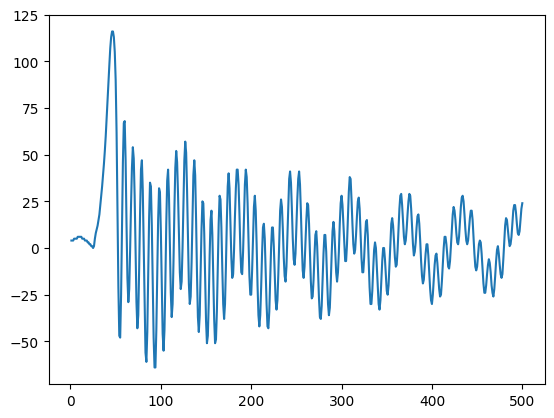

In [4]:
import matplotlib.pyplot as plt

string1df = pd.read_csv(r"./csvs2\string1_positions.csv")
plt.plot(string1df['frame'][0:500], string1df['dx_from_ref'][0:500])

In [2]:
# Detect positions for no load

noloadpath = rf"C:\Users\Justine Elvena\Desktop\Acads\UPD\Sem4.1\Physics192\Inertial Balance\Vids\noload.MOV"
output_dir = r'./csvs2'
recordSingleShowFrames(noloadpath, output_dir)

Resized frame to 1200x675
🖱️ Click the reference point (black dot) in the window.
Point selected: (694, 248)
✅ Reference point: (694, 248)
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Res

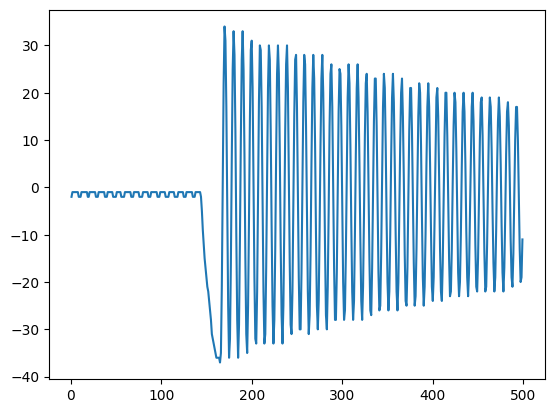

In [5]:
noloaddf = pd.read_csv(r"./csvs2\noload_positions.csv")
plt.plot(noloaddf['frame'][0:500], noloaddf['dx_from_ref'][0:500])

In [6]:
# Detect positions for string2

string2path = rf"C:\Users\Justine Elvena\Desktop\Acads\UPD\Sem4.1\Physics192\Inertial Balance\Vids\string2.MOV"
output_dir = r'./csvs2'
recordSingleShowFrames(string2path, output_dir)

Resized frame to 1200x675
🖱️ Click the reference point (black dot) in the window.
Point selected: (641, 296)
✅ Reference point: (641, 296)
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Resized frame to 1200x675
Res